# Early Warning System for Pandemic Risk Using WHO Surveillance Data

## Team

| Name | GitHub ID | Role |
|------|-----------|------|
| **Jayesh Vinod Sawarkar** | [jayeshsawarkar](https://github.com/jayeshsawarkar) | **Point of Contact (POC)** |
| Roshni Ramesh More | [RoshniRMore](https://github.com/RoshniRMore) | Team Member |
| Insha Maniyar | [inshamaniyar77](https://github.com/inshamaniyar77) | Team Member |

## Overview

### What are we trying to do?
We are building an early warning system that uses public disease surveillance data to detect whether case patterns are moving toward a surge. The goal is to identify risk **before** an outbreak fully peaks, so that public health teams can respond earlier.

### What is new in our approach, and why might it work?
Instead of only describing past case counts, we turn surveillance data into a forward-looking prediction problem. We engineer time-based features such as recent trends, growth rates, rolling averages, abnormality scores, and an estimated reproduction signal (`Rt`), then test whether these features can predict future surge conditions. We also evaluate whether patterns learned from one disease (COVID-19) can transfer to another disease (RSV), which is a more realistic test of generalizability.

### Who cares, and what need are we addressing?
Our main stakeholders are **public health agencies, emergency response teams, and policy planners** who need interpretable early signals for preparedness, resource allocation, and outbreak monitoring. If successful, this work could support earlier interventions and better situational awareness.

### What has changed since the proposal?
Compared with the proposal, the project has become more concrete in two ways:
1. We moved from a broad concept into an implemented modeling pipeline with baseline classification and regression models.
2. We added an explicit **cross-disease evaluation** using Australia RSV data, which helps us test whether the system captures transferable outbreak dynamics instead of memorizing COVID-only behavior.


## Data

### Primary datasets
1. **WHO COVID-19 Global Daily Data**  
   Source: [WHO COVID-19 Dashboard](https://data.who.int/dashboards/covid19/data)  
   ~75,000 weekly records across 240 countries (Jan 2020 – Jan 2026).  
   Used for model training across 239 countries.

2. **Australia NNDSS Fortnightly Reports**  
   Source: [Australian Dept of Health — NNDSS](https://www.health.gov.au/resources/collections/nndss-fortnightly-reports)  
   76 nationally notifiable diseases, fortnightly resolution (Dec 2023 – Nov 2025).  
   Legally mandated under the National Health Security Act 2007.  
   Used for disease-specific testing on Australia COVID and Australia RSV.

3. **World Population Data**  
   Source: [World Bank via GitHub datasets](https://github.com/datasets/population)  
   16,930 rows covering 1960–2023 for all countries.  
   Used to normalize raw case counts into `cases_per_100k`, making cross-country comparisons meaningful.

### Why we consider these data credible
- WHO is an internationally recognized public health authority with standardized reporting practices across member nations.
- NNDSS is an official national surveillance system maintained by the Australian government, with multi-level quality control (practitioner → state → national).
- Population data comes from the World Bank, a widely used source for demographic statistics.
- We explicitly acknowledge the limitations of surveillance data, including reporting delays, under-reporting, and changes in testing/reporting behavior (e.g., Australia's shift from mandatory PCR to rapid antigen tests in early 2022).

### What we examine in EDA
For the checkpoint, we focus on the patterns that matter most for modeling:
- dataset coverage and scale,
- distributions of key features (cases, Rt, growth rates),
- correlation structure among engineered features,
- the frequency of surge weeks and regional variation,
- and visual comparisons between training data and held-out Australian test sets.

In [1]:
# Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               RandomForestRegressor, GradientBoostingRegressor)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, precision_recall_curve,
                              mean_absolute_error, mean_squared_error, r2_score)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier, XGBRegressor

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print("All libraries imported (classification + regression)")

All libraries imported (classification + regression)


In [2]:
# Paths
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "checkpoint" else Path(r"/mnt/data/inferra_proj/group-project-inferra-main")
WHO_PATH     = PROJECT_ROOT / "Data" / "WHO_COVID19_cleaned.csv"
RSV_PATH     = PROJECT_ROOT / "Data" / "AUS_rsv.xlsx"
MEASLES_PATH = PROJECT_ROOT / "Data" / "AUS_measles.xlsx"
POP_PATH     = PROJECT_ROOT / "Data" / "population.csv"
OUTPUT_PATH  = PROJECT_ROOT / "Data" / "features_global.csv"
print("Project root:", PROJECT_ROOT)

Project root: /Users/jayeshsawarkar/Desktop/IST707 AML/PROJECT/group-project-inferra


### Preprocessing pipeline
The core preprocessing step is to convert raw disease counts into a modeling-ready time series per country/disease. The main transformations are:
- sorting data chronologically,
- merging population values,
- creating normalized case rates (`cases_per_100k`),
- generating lag, rolling, growth, abnormality, and seasonality features,
- and creating surge labels for classification.

The next code cell contains the shared feature engineering functions used throughout the notebook.


In [3]:
# Core Functions (Feature Engineering + Rt + Labels)
# ============================================================
# These functions are applied to EVERY country and EVERY disease.
# They are disease-agnostic -- same logic for COVID, RSV, Measles.
# All features are now built on cases_per_100k for cross-country comparability.

AUS_POPULATION = 26_473_055  # 2023 estimate


def build_features_for_series(dates, cases, country='Unknown', disease='Unknown',
                               population=None):
    """
    Build lag-safe feature matrix from any weekly/biweekly case time series.
    All features use only past data -- no future leakage.

    If population is provided, features are built on cases_per_100k.
    Otherwise raw cases are used (backward compatible).
    """
    df = pd.DataFrame({'Date': dates, 'Cases': cases}).sort_values('Date').reset_index(drop=True)
    df['Cases'] = df['Cases'].clip(lower=0)

    # Population normalization
    if population and population > 0:
        df['cases_per_100k'] = (df['Cases'] / population) * 100_000
    else:
        df['cases_per_100k'] = df['Cases']  # fallback to raw

    feat = df['cases_per_100k']

    # Lag features -- 6 lags of history
    for lag in [1, 2, 3, 4, 5, 6]:
        df[f'lag_{lag}'] = feat.shift(lag)

    # Rolling statistics
    df['roll2_mean']  = feat.rolling(2).mean()
    df['roll4_mean']  = feat.rolling(4).mean()
    df['roll4_std']   = feat.rolling(4).std().replace(0, np.nan)
    df['roll8_mean']  = feat.rolling(8).mean()
    df['roll12_mean'] = feat.rolling(12).mean()

    # Growth rates
    df['growth_1w'] = feat / feat.shift(1).replace(0, np.nan)
    df['growth_4w'] = feat / feat.shift(4).replace(0, np.nan)

    # Z-score -- anomaly detection (12-week baseline for stability)
    df['zscore'] = (feat - df['roll12_mean']) / df['roll4_std']

    # Seasonality -- cyclical encoding
    week_num       = df['Date'].dt.isocalendar().week.astype(int)
    df['week_sin'] = np.sin(2 * np.pi * week_num / 52)
    df['week_cos'] = np.cos(2 * np.pi * week_num / 52)

    # Rt estimation -- serial interval 5.5 days for respiratory diseases
    cases_c = feat.clip(lower=0.001)
    rt_vals = []
    for i in range(len(df)):
        if i < 4:
            rt_vals.append(np.nan)
            continue
        wc          = cases_c.iloc[i - 4: i + 1].values
        slope       = np.polyfit(np.arange(5), np.log(wc + 1), 1)[0]
        period_days = (df['Date'].iloc[i] - df['Date'].iloc[i - 4]).days / 4
        r_per_day   = slope / max(period_days, 1)
        rt_vals.append(np.clip(np.exp(r_per_day * 5.5), 0.1, 10.0))
    df['Rt'] = rt_vals

    # Regression targets -- predict cases_per_100k H weeks into the future
    for h in [2, 4, 6, 8]:
        df[f'y_{h}'] = feat.shift(-h)

    df['Country'] = country
    df['Disease'] = disease

    return df.dropna(subset=['lag_6']).reset_index(drop=True)


def label_surges(df, rt_threshold=1.2, min_duration=3):
    """Label surge periods: Rt > threshold for min_duration consecutive periods."""
    df = df.copy()
    df['surge'] = 0
    run, run_start = 0, None
    for i, row in df.iterrows():
        if pd.notna(row['Rt']) and row['Rt'] > rt_threshold:
            run += 1
            if run_start is None:
                run_start = i
        else:
            if run_start is not None and run >= min_duration:
                df.loc[run_start: i - 1, 'surge'] = 1
            run, run_start = 0, None
    if run_start is not None and run >= min_duration:
        df.loc[run_start:, 'surge'] = 1
    return df


def label_surges_zscore(df, z_threshold=1.5, min_duration=2):
    """Z-score based surge detection -- for short series where Rt method lacks data."""
    df = df.copy()
    df['surge'] = 0
    run, run_start = 0, None
    for i, row in df.iterrows():
        if pd.notna(row['zscore']) and row['zscore'] > z_threshold:
            run += 1
            if run_start is None:
                run_start = i
        else:
            if run_start is not None and run >= min_duration:
                df.loc[run_start: i - 1, 'surge'] = 1
            run, run_start = 0, None
    if run_start is not None and run >= min_duration:
        df.loc[run_start:, 'surge'] = 1
    return df


def melt_biweekly(wide_df):
    """Convert NNDSS-style wide table (FN01_2024...) to long format."""
    long = wide_df.melt(id_vars='Disease_Name', var_name='Period', value_name='Cases')
    def fn_to_date(period):
        parts = period.split('_')
        fn_num = int(parts[0][2:])
        year = int(parts[1])
        day_of_year = (fn_num - 1) * 14 + 1
        return pd.Timestamp(f'{year}-01-01') + pd.Timedelta(days=day_of_year - 1)
    long['Date'] = long['Period'].apply(fn_to_date)
    long['Cases'] = pd.to_numeric(long['Cases'], errors='coerce').fillna(0)
    return long.sort_values('Date').reset_index(drop=True)


print("Core functions defined: build_features_for_series, label_surges, label_surges_zscore, melt_biweekly")
print("Features now built on cases_per_100k | 6 lags | roll2/4/8/12 | 12-week zscore | regression targets y_2/4/6/8")


Core functions defined: build_features_for_series, label_surges, label_surges_zscore, melt_biweekly
Features now built on cases_per_100k | 6 lags | roll2/4/8/12 | 12-week zscore | regression targets y_2/4/6/8


### Data loading and validation
We first load the WHO, NNDSS, and population datasets and verify their coverage. This helps confirm that the training data are broad enough for global learning and that the Australian disease files can support held-out testing.


In [4]:
# Load All Data
# ============================================================

# Load WHO global COVID data
who = pd.read_csv(WHO_PATH, parse_dates=['Date_reported'])
who = who.sort_values(['Country', 'Date_reported']).reset_index(drop=True)

# Load Australian disease data
rsv_wide     = pd.read_excel(RSV_PATH)
measles_wide = pd.read_excel(MEASLES_PATH)

# Load population data
# Source: https://github.com/datasets/population (World Bank via UN)
# Columns: Country Name, Country Code, Year, Value
pop_raw = pd.read_csv(POP_PATH)
print(f"Population data: {pop_raw.shape[0]:,} rows, years {pop_raw['Year'].min()}-{pop_raw['Year'].max()}")

# Get latest population per country
pop_latest = (pop_raw
    .sort_values('Year', ascending=False)
    .drop_duplicates(subset='Country Name', keep='first')
    .rename(columns={'Country Name': 'Country', 'Value': 'Population'})
    [['Country', 'Population']]
)

# Handle name mismatches between WHO and World Bank
name_fixes = {
    'United States of America': 'United States',
    'Iran (Islamic Republic of)': 'Iran, Islamic Rep.',
    'Republic of Korea': 'Korea, Rep.',
    "Democratic People\'s Republic of Korea": "Korea, Dem. People\'s Rep.",
    'United Kingdom of Great Britain and Northern Ireland': 'United Kingdom',
    'Viet Nam': 'Vietnam',
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Venezuela (Bolivarian Republic of)': 'Venezuela, RB',
    'Czechia': 'Czech Republic',
    "Cote dIvoire": "Cote dIvoire",
    'Republic of Moldova': 'Moldova',
    "Lao People\'s Democratic Republic": 'Lao PDR',
    'occupied Palestinian territory, including east Jerusalem': 'West Bank and Gaza',
    'Micronesia (Federated States of)': 'Micronesia, Fed. Sts.',
    'Congo': 'Congo, Rep.',
    'The United Kingdom': 'United Kingdom',
}

who['Country_lookup'] = who['Country'].map(name_fixes).fillna(who['Country'])
who = who.merge(pop_latest, left_on='Country_lookup', right_on='Country',
                how='left', suffixes=('', '_pop'))
who.drop(columns=['Country_pop', 'Country_lookup'], inplace=True, errors='ignore')

# Fill missing populations with median (small territories)
median_pop = who['Population'].median()
missing_pop = who[who['Population'].isna()]['Country'].unique()
if len(missing_pop) > 0:
    print(f"\nCountries without population match ({len(missing_pop)}):")
    for c in sorted(missing_pop)[:10]:
        print(f"  - {c}")
    if len(missing_pop) > 10:
        print(f"  ... and {len(missing_pop)-10} more")
    print(f"  Filling with median population: {median_pop:,.0f}")
    who['Population'] = who['Population'].fillna(median_pop)

print(f"\nWHO Global COVID  : {who.shape[0]:,} rows | {who['Country'].nunique()} countries")
print(f"Date range        : {who['Date_reported'].min().date()} -> {who['Date_reported'].max().date()}")
print(f"Population merged : {who['Population'].notna().sum():,} / {len(who):,} rows")
print(f"RSV fortnights    : {rsv_wide.shape}")
print(f"Measles fortnights: {measles_wide.shape}")


Population data: 16,930 rows, years 1960-2023

Countries without population match (46):
  - Anguilla
  - Bahamas
  - Bonaire, Saint Eustatius and Saba
  - Cook Islands
  - Cura�ao
  - Czechia
  - C�te d'Ivoire
  - Democratic Republic of the Congo
  - Egypt
  - Falkland Islands (Malvinas)
  ... and 36 more
  Filling with median population: 6,723,398

WHO Global COVID  : 75,840 rows | 240 countries
Date range        : 2020-01-05 -> 2026-01-18
Population merged : 75,840 / 75,840 rows
RSV fortnights    : (1, 50)
Measles fortnights: (1, 50)


### Build training and held-out test sets
We train primarily on global COVID-19 data from all countries **except Australia**. Australia is held out so we can test geographic generalization. We also construct a second test set using Australian RSV data to test cross-disease transfer.


In [5]:
# Build Training Data (All COVID Countries Except Australia)
# ============================================================
# Features built on cases_per_100k for cross-country comparability.
# Australia held out completely for testing.

print("Building features for all countries (excluding Australia)...")
print("Features built on cases_per_100k (population-normalized)")
print("This takes ~30-60 seconds...\n")

TRAIN_COUNTRIES = who[who['Country'] != 'Australia']['Country'].unique()
TEST_COUNTRY    = 'Australia'

all_train = []
surge_counts = []
skipped = 0

for i, country in enumerate(TRAIN_COUNTRIES):
    sub = who[who['Country'] == country].copy()
    pop = sub['Population'].iloc[0] if sub['Population'].notna().any() else None

    feat_df = build_features_for_series(
        sub['Date_reported'], sub['New_cases'],
        country=country, disease='COVID-19',
        population=pop
    )

    if len(feat_df) < 10:
        skipped += 1
        continue

    feat_df = label_surges(feat_df)
    all_train.append(feat_df)
    surge_counts.append(feat_df['surge'].mean() * 100)

    if (i + 1) % 50 == 0:
        print(f"  Processed {i+1}/{len(TRAIN_COUNTRIES)} countries...")

train_df = pd.concat(all_train, ignore_index=True)

print(f"\n Training data built")
print(f"   Countries used  : {len(all_train)}  (skipped {skipped} with <10 rows)")
print(f"   Total rows      : {len(train_df):,}")
print(f"   Surge weeks     : {train_df['surge'].sum():,}  ({train_df['surge'].mean()*100:.1f}%)")
print(f"   Normal weeks    : {(train_df['surge']==0).sum():,}")
print(f"   Avg surge % per country: {np.mean(surge_counts):.1f}%")


Building features for all countries (excluding Australia)...
Features built on cases_per_100k (population-normalized)
This takes ~30-60 seconds...

  Processed 50/239 countries...
  Processed 100/239 countries...
  Processed 150/239 countries...
  Processed 200/239 countries...

 Training data built
   Countries used  : 239  (skipped 0 with <10 rows)
   Total rows      : 74,090
   Surge weeks     : 5,010  (6.8%)
   Normal weeks    : 69,080
   Avg surge % per country: 6.8%


In [6]:
# Build Test Set 1: Australia COVID
# ============================================================
aus_covid = who[who['Country'] == TEST_COUNTRY].copy()
aus_pop = aus_covid['Population'].iloc[0]

test_covid = build_features_for_series(
    aus_covid['Date_reported'], aus_covid['New_cases'],
    country='Australia', disease='COVID-19',
    population=aus_pop
)
test_covid = label_surges(test_covid)

print(f"   Test Set 1: Australia COVID")
print(f"   Population  : {aus_pop:,.0f}")
print(f"   Rows        : {len(test_covid)}")
print(f"   Date range  : {test_covid['Date'].min().date()} -> {test_covid['Date'].max().date()}")
print(f"   Surge weeks : {test_covid['surge'].sum()}  ({test_covid['surge'].mean()*100:.1f}%)")


   Test Set 1: Australia COVID
   Population  : 26,658,948
   Rows        : 310
   Date range  : 2020-02-16 -> 2026-01-18
   Surge weeks : 27  (8.7%)


In [7]:
# Build Test Set 2: Australia RSV
# ============================================================
rsv_long = melt_biweekly(rsv_wide)
rsv_sub  = rsv_long[rsv_long['Disease_Name'] == 'Respiratory syncytial virus (RSV)']

test_rsv = build_features_for_series(
    rsv_sub['Date'], rsv_sub['Cases'],
    country='Australia', disease='RSV',
    population=AUS_POPULATION
)
test_rsv = label_surges_zscore(test_rsv, z_threshold=1.5, min_duration=2)

print(f"   Test Set 2: Australia RSV")
print(f"   Rows        : {len(test_rsv)}")
print(f"   Surge weeks : {test_rsv['surge'].sum()}  ({test_rsv['surge'].mean()*100:.1f}%)")


   Test Set 2: Australia RSV
   Rows        : 43
   Surge weeks : 14  (32.6%)


### Exploratory data analysis
The first plot compares the overall shape of the training and testing time series. This gives a quick view of scale, seasonality, and where surges appear in each dataset.


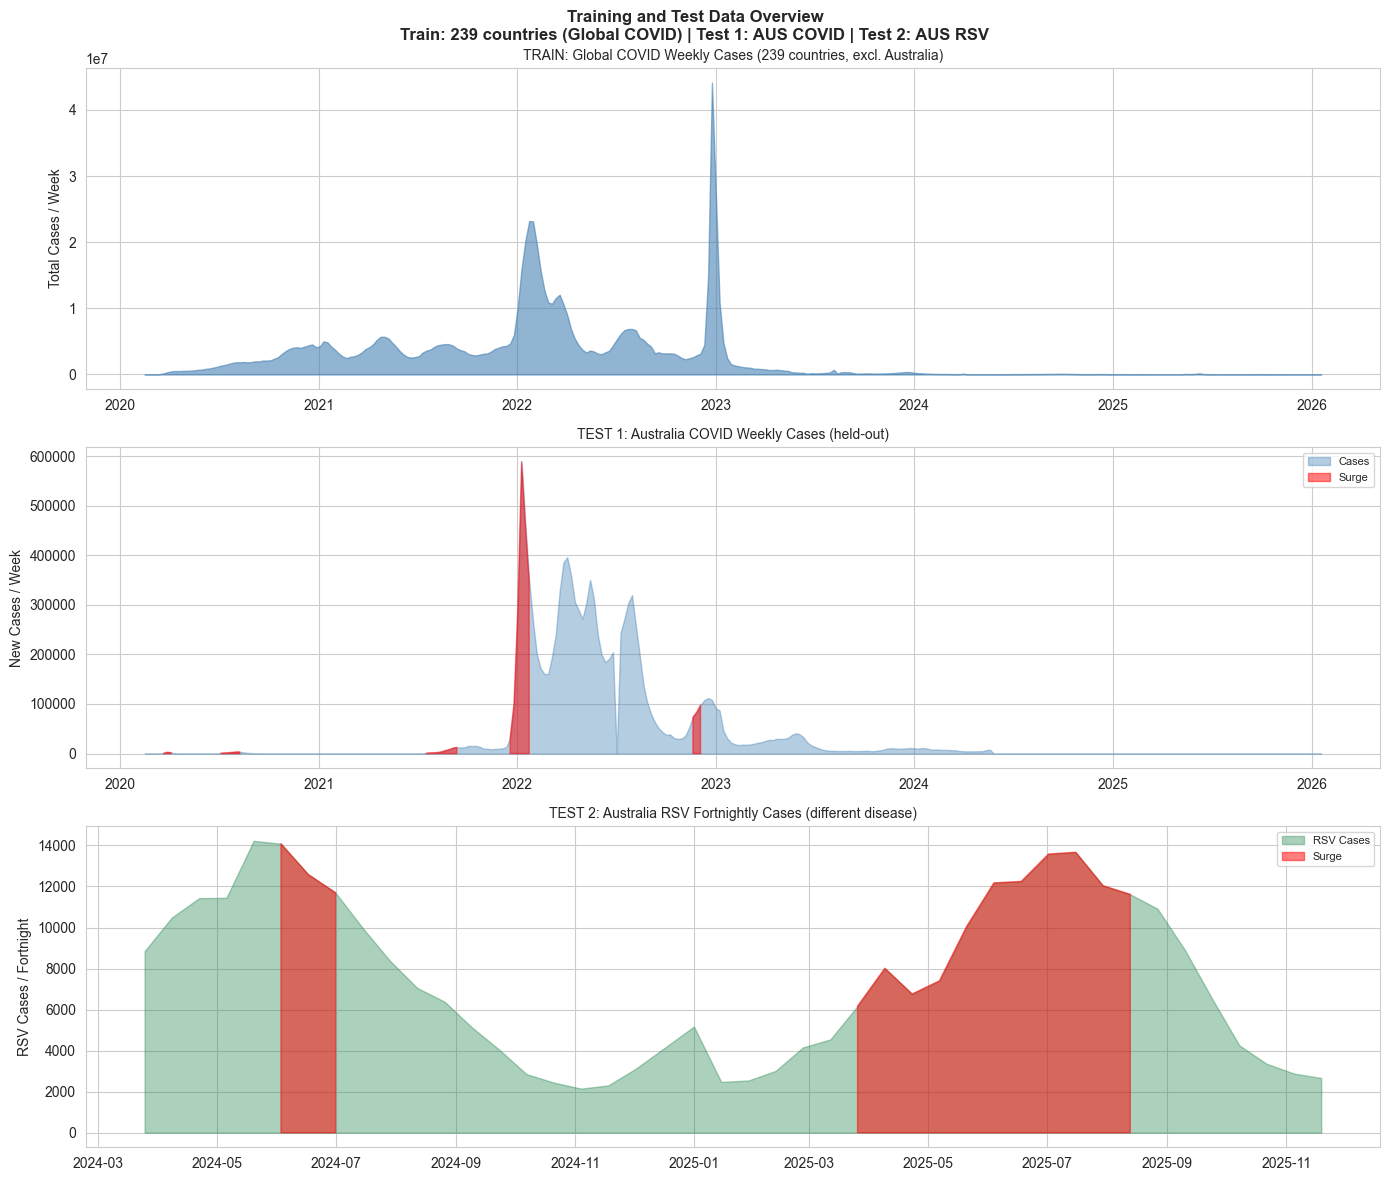

In [8]:
# EDA: Visualize All Three Datasets
# ============================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle("Training and Test Data Overview\n"
             "Train: 239 countries (Global COVID) | Test 1: AUS COVID | Test 2: AUS RSV",
             fontsize=12, fontweight='bold')

# Panel 1: Global COVID weekly cases (sum across all training countries)
global_weekly = (train_df.groupby('Date')['Cases'].sum())
axes[0].fill_between(global_weekly.index, global_weekly.values,
                     alpha=0.6, color='steelblue')
axes[0].set_title(f'TRAIN: Global COVID Weekly Cases (239 countries, excl. Australia)', fontsize=10)
axes[0].set_ylabel('Total Cases / Week')

# Panel 2: Australia COVID
surge_mask = test_covid['surge'] == 1
axes[1].fill_between(test_covid['Date'], test_covid['Cases'],
                     alpha=0.4, color='steelblue', label='Cases')
axes[1].fill_between(test_covid['Date'], test_covid['Cases'],
                     where=surge_mask, alpha=0.5, color='red', label='Surge')
axes[1].set_title('TEST 1: Australia COVID Weekly Cases (held-out)', fontsize=10)
axes[1].set_ylabel('New Cases / Week')
axes[1].legend(fontsize=8)

# Panel 3: Australia RSV
rsv_surge_mask = test_rsv['surge'] == 1
axes[2].fill_between(test_rsv['Date'], test_rsv['Cases'],
                     alpha=0.4, color='seagreen', label='RSV Cases')
axes[2].fill_between(test_rsv['Date'], test_rsv['Cases'],
                     where=rsv_surge_mask, alpha=0.5, color='red', label='Surge')
axes[2].set_title('TEST 2: Australia RSV Fortnightly Cases (different disease)', fontsize=10)
axes[2].set_ylabel('RSV Cases / Fortnight')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


The next visualization summarizes how surge frequency differs across WHO regions. This matters because the model is being trained on a globally heterogeneous dataset, not a single-country case series.


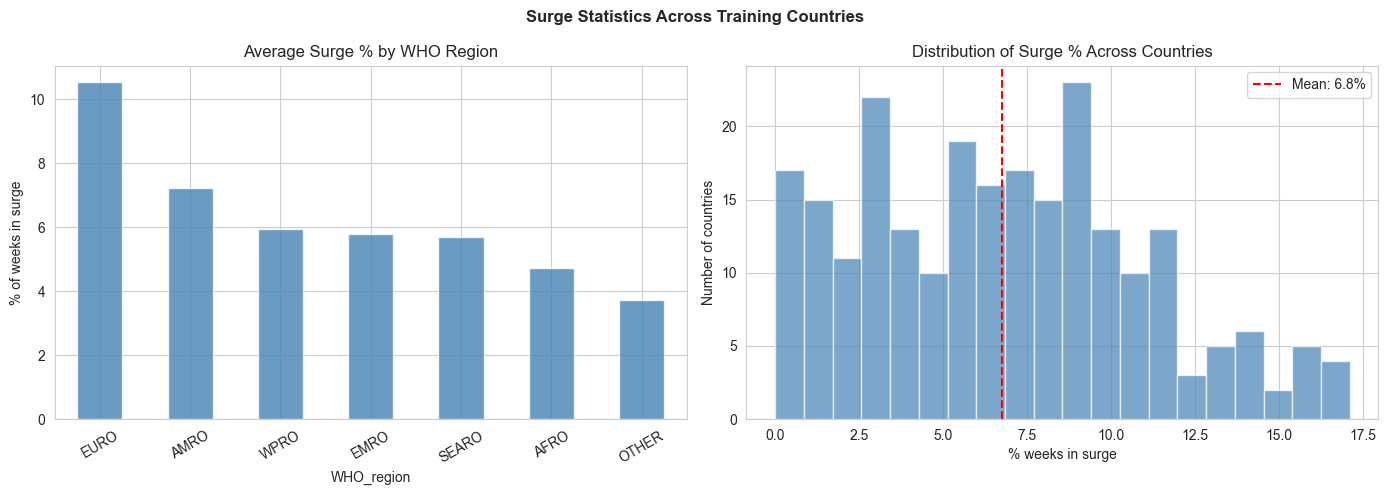

Surge % by region:
WHO_region
EURO     10.5
AMRO      7.2
WPRO      5.9
EMRO      5.8
SEARO     5.7
AFRO      4.7
OTHER     3.7


In [9]:
# EDA: Surge Statistics Across Training Countries
# ============================================================
# Show how surge patterns vary across regions — justifies global training.

region_surge = (train_df.groupby('Country')
                .agg(surge_pct=('surge', 'mean'))
                .reset_index())
region_surge['surge_pct'] *= 100

# Merge region info
region_map = who[['Country','WHO_region']].drop_duplicates()
region_surge = region_surge.merge(region_map, on='Country', how='left')

region_avg = region_surge.groupby('WHO_region')['surge_pct'].mean().sort_values(ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Surge Statistics Across Training Countries",
             fontsize=12, fontweight='bold')

region_avg.plot(kind='bar', ax=ax1, color='steelblue', alpha=0.8, edgecolor='white')
ax1.set_title('Average Surge % by WHO Region')
ax1.set_ylabel('% of weeks in surge')
ax1.tick_params(axis='x', rotation=30)

region_surge['surge_pct'].hist(bins=20, ax=ax2, color='steelblue', alpha=0.7, edgecolor='white')
ax2.axvline(region_surge['surge_pct'].mean(), color='red', linestyle='--',
            label=f"Mean: {region_surge['surge_pct'].mean():.1f}%")
ax2.set_title('Distribution of Surge % Across Countries')
ax2.set_xlabel('% weeks in surge')
ax2.set_ylabel('Number of countries')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Surge % by region:")
print(region_avg.round(1).to_string())

### Feature distributions and correlations
We next examine the distributions of our key engineered features and their correlation structure. Understanding distributions helps identify skewness or outliers that might affect model performance, while the correlation matrix reveals which features are redundant and which provide independent signal.

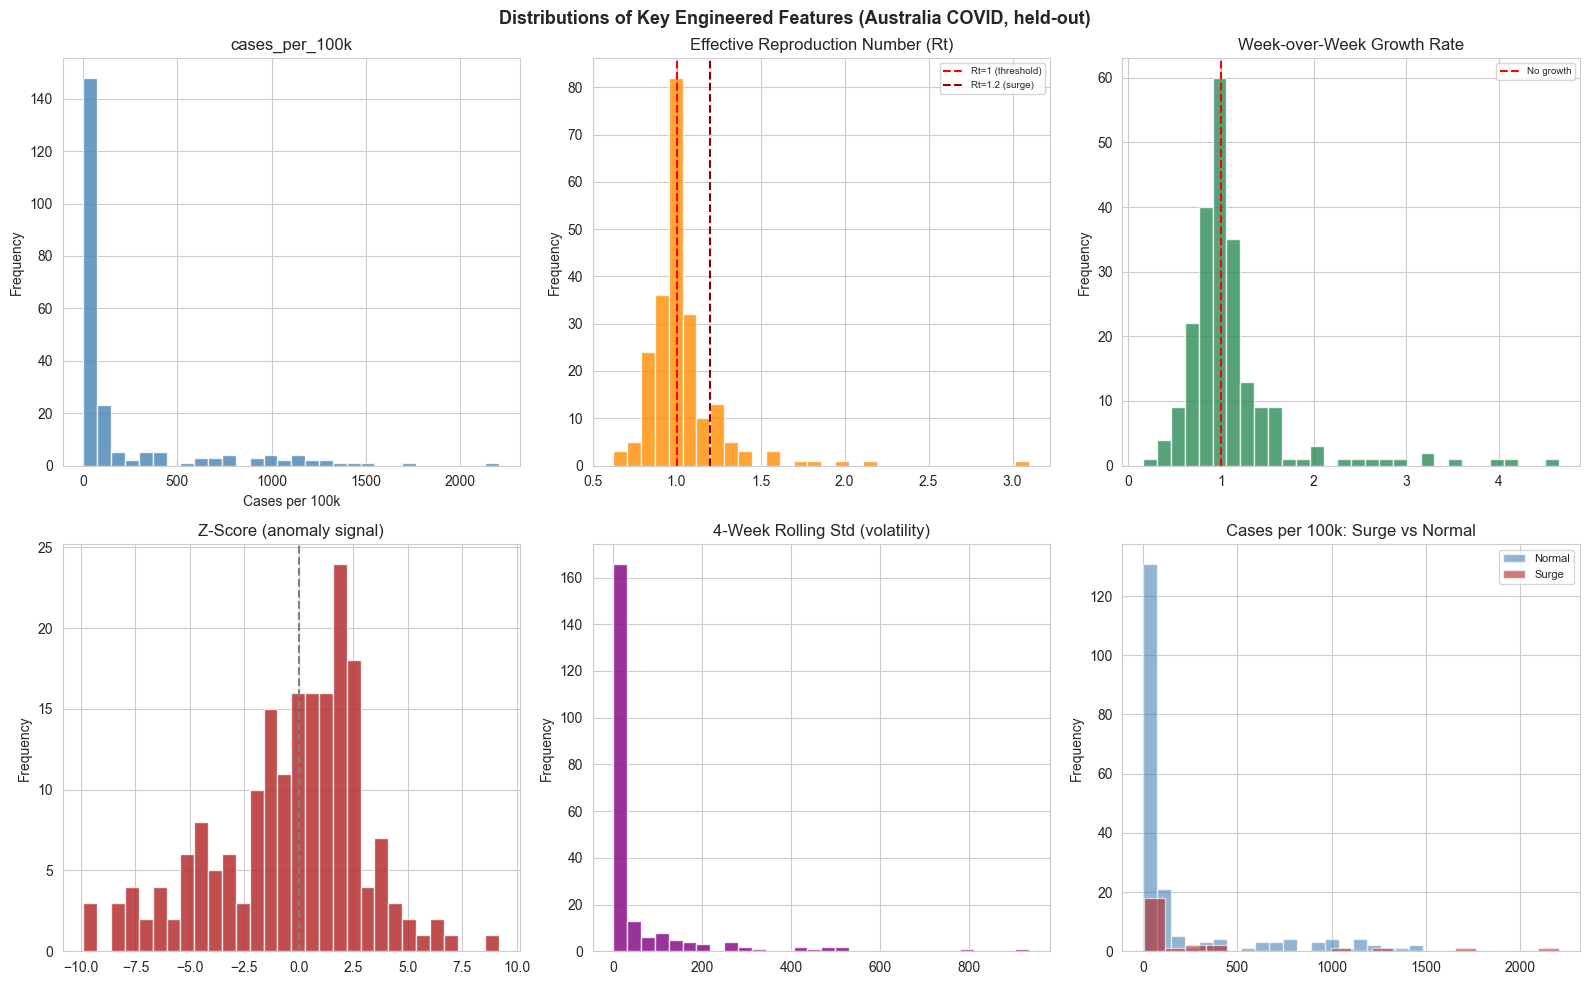

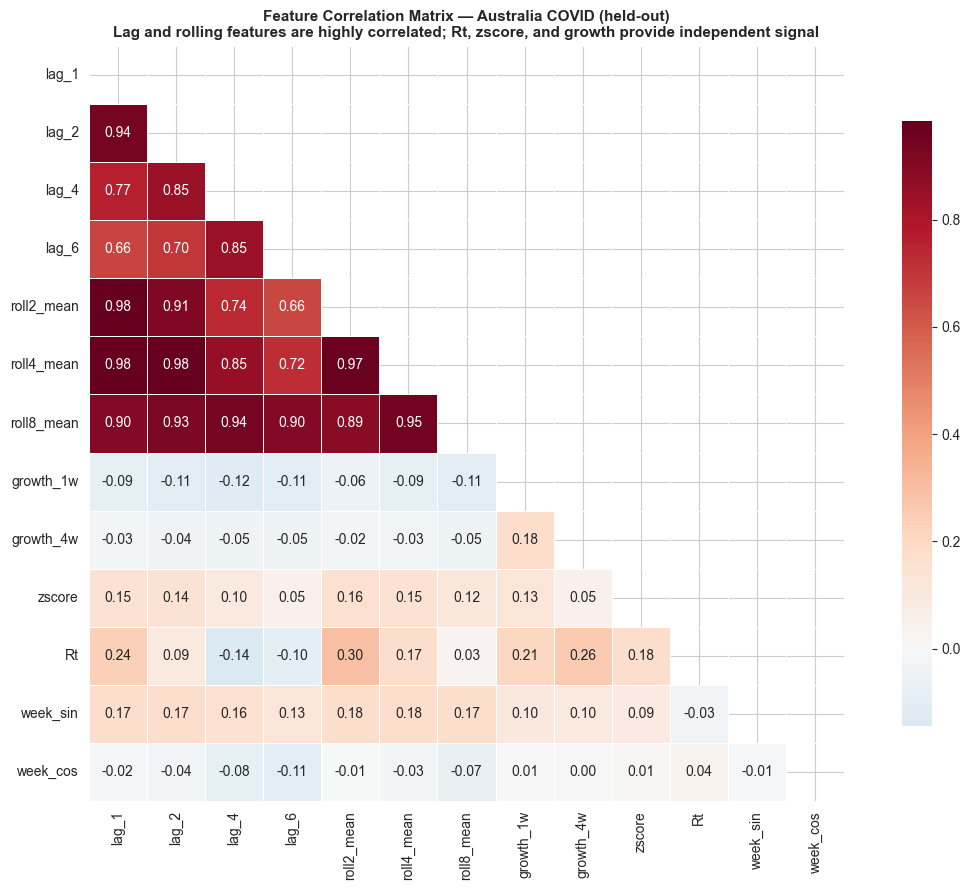

Key observations:
  - Lag features (lag_1 through lag_6) and rolling means are highly correlated (r > 0.9)
    This is expected — they all track recent case levels
  - Rt and growth_1w are moderately correlated (both measure momentum)
  - zscore has low correlation with other features — valuable independent signal
  - Seasonal features (week_sin, week_cos) are independent of all case-based features


In [10]:
# Feature Distributions and Correlation Analysis
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Distributions of Key Engineered Features (Australia COVID, held-out)",
             fontsize=13, fontweight='bold')

# Filter to active periods only (cases > 0)
active = test_covid[test_covid['Cases'] > 0].copy()

# 1. cases_per_100k
axes[0,0].hist(active['cases_per_100k'], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
axes[0,0].set_title('cases_per_100k')
axes[0,0].set_xlabel('Cases per 100k')

# 2. Rt distribution
valid_rt = active[active['Rt'].notna() & (active['Rt'] < 5)]
axes[0,1].hist(valid_rt['Rt'], bins=30, color='darkorange', edgecolor='white', alpha=0.8)
axes[0,1].axvline(x=1.0, color='red', linestyle='--', label='Rt=1 (threshold)')
axes[0,1].axvline(x=1.2, color='darkred', linestyle='--', label='Rt=1.2 (surge)')
axes[0,1].set_title('Effective Reproduction Number (Rt)')
axes[0,1].legend(fontsize=7)

# 3. growth_1w
valid_growth = active[active['growth_1w'].notna() & (active['growth_1w'] < 10)]
axes[0,2].hist(valid_growth['growth_1w'], bins=30, color='seagreen', edgecolor='white', alpha=0.8)
axes[0,2].axvline(x=1.0, color='red', linestyle='--', label='No growth')
axes[0,2].set_title('Week-over-Week Growth Rate')
axes[0,2].legend(fontsize=7)

# 4. zscore
valid_z = active[active['zscore'].notna() & (active['zscore'].abs() < 10)]
axes[1,0].hist(valid_z['zscore'], bins=30, color='firebrick', edgecolor='white', alpha=0.8)
axes[1,0].axvline(x=0, color='gray', linestyle='--')
axes[1,0].set_title('Z-Score (anomaly signal)')

# 5. roll4_std (volatility)
valid_std = active[active['roll4_std'].notna()]
axes[1,1].hist(valid_std['roll4_std'], bins=30, color='purple', edgecolor='white', alpha=0.8)
axes[1,1].set_title('4-Week Rolling Std (volatility)')

# 6. Surge vs non-surge comparison
surge_cases = active[active['surge']==1]['cases_per_100k']
normal_cases = active[active['surge']==0]['cases_per_100k']
axes[1,2].hist(normal_cases, bins=20, color='steelblue', alpha=0.6, label='Normal', edgecolor='white')
axes[1,2].hist(surge_cases, bins=20, color='firebrick', alpha=0.6, label='Surge', edgecolor='white')
axes[1,2].set_title('Cases per 100k: Surge vs Normal')
axes[1,2].legend(fontsize=8)

for ax in axes.flat:
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

# ---- Correlation Heatmap ----
corr_features = [
    'lag_1', 'lag_2', 'lag_4', 'lag_6',
    'roll2_mean', 'roll4_mean', 'roll8_mean',
    'growth_1w', 'growth_4w',
    'zscore', 'Rt', 'week_sin', 'week_cos'
]

corr_matrix = test_covid[corr_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix — Australia COVID (held-out)\n'
             'Lag and rolling features are highly correlated; Rt, zscore, and growth provide independent signal',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key observations:")
print("  - Lag features (lag_1 through lag_6) and rolling means are highly correlated (r > 0.9)")
print("    This is expected — they all track recent case levels")
print("  - Rt and growth_1w are moderately correlated (both measure momentum)")
print("  - zscore has low correlation with other features — valuable independent signal")
print("  - Seasonal features (week_sin, week_cos) are independent of all case-based features")

## Modeling
We frame the project as two related tasks:
1. **Classification** — detect whether a given period is a surge.
2. **Regression** — estimate the magnitude of future disease activity.

We use simple but strong baselines first: logistic regression, tree-based classifiers, boosting models, ridge regression, SVR, and ensemble regressors.


In [11]:
# Define Features and Models
# ============================================================

FEATURE_COLS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6',
    'roll2_mean', 'roll4_mean', 'roll4_std', 'roll8_mean',
    'growth_1w', 'growth_4w',
    'zscore', 'week_sin', 'week_cos', 'Rt'
]
TARGET_COL = 'surge'

# ---- Classification Models (surge yes/no) ----
MODELS = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(class_weight='balanced',
                                      max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(n_estimators=200,
                                          class_weight='balanced',
                                          random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    GradientBoostingClassifier(n_estimators=200,
                                              max_depth=4, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    XGBClassifier(n_estimators=200, max_depth=4,
                                  use_label_encoder=False,
                                  eval_metric='logloss', random_state=42,
                                  scale_pos_weight=8))
    ])
}

# ---- Regression Models (predict cases_per_100k H weeks ahead) ----
REG_MODELS = {
    'Ridge Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('reg',    Ridge(alpha=1.0))
    ]),
    'SVR (RBF)': Pipeline([
        ('scaler', StandardScaler()),
        ('reg',    SVR(kernel='rbf', C=10.0, epsilon=0.1))
    ]),
    'Random Forest Reg': Pipeline([
        ('scaler', StandardScaler()),
        ('reg',    RandomForestRegressor(n_estimators=200, random_state=42))
    ]),
    'Gradient Boosting Reg': Pipeline([
        ('scaler', StandardScaler()),
        ('reg',    GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                              random_state=42))
    ]),
    'XGBoost Reg': Pipeline([
        ('scaler', StandardScaler()),
        ('reg',    XGBRegressor(n_estimators=200, max_depth=4,
                                 random_state=42))
    ])
}

print(f"Classification models: {list(MODELS.keys())}")
print(f"Regression models:     {list(REG_MODELS.keys())}")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")


Classification models: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Regression models:     ['Ridge Regression', 'SVR (RBF)', 'Random Forest Reg', 'Gradient Boosting Reg', 'XGBoost Reg']
Features (16): ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'roll2_mean', 'roll4_mean', 'roll4_std', 'roll8_mean', 'growth_1w', 'growth_4w', 'zscore', 'week_sin', 'week_cos', 'Rt']


In [12]:
# Train All Models on Global COVID Data
# ============================================================

print("=" * 55)
print("  TRAINING: Classification (surge detection)")
print("=" * 55)

train_clean = train_df[FEATURE_COLS + [TARGET_COL]].dropna().reset_index(drop=True)
X_train = train_clean[FEATURE_COLS]
y_train = train_clean[TARGET_COL]

print(f"  Training samples : {len(X_train):,}")
print(f"  Surge %          : {y_train.mean()*100:.1f}%")

try:
    sm = SMOTE(random_state=42, k_neighbors=2)
    X_res, y_res = sm.fit_resample(X_train, y_train)
    print(f"  After SMOTE      : {len(X_res):,} samples (balanced)")
except Exception as e:
    print(f"  SMOTE failed ({e}), using original data")
    X_res, y_res = X_train, y_train

trained_models = {}
for model_name, model in MODELS.items():
    model.fit(X_res, y_res)
    trained_models[model_name] = model
    print(f"  + {model_name} trained")

# ---- Regression Training ----
print()
print("=" * 55)
print("  TRAINING: Regression (surge size prediction)")
print("=" * 55)

REG_TARGET = 'y_4'
train_reg = train_df[FEATURE_COLS + [REG_TARGET]].dropna().reset_index(drop=True)
X_train_reg = train_reg[FEATURE_COLS]
y_train_reg = train_reg[REG_TARGET]

print(f"  Training samples : {len(X_train_reg):,}")
print(f"  Target (y_4) stats: mean={y_train_reg.mean():.2f}, std={y_train_reg.std():.2f}")

trained_reg_models = {}
for model_name, model in REG_MODELS.items():
    model.fit(X_train_reg, y_train_reg)
    trained_reg_models[model_name] = model
    print(f"  + {model_name} trained")

print()
print("All models trained")


  TRAINING: Classification (surge detection)
  Training samples : 40,657
  Surge %          : 10.6%
  After SMOTE      : 72,656 samples (balanced)
  + Logistic Regression trained
  + Random Forest trained
  + Gradient Boosting trained
  + XGBoost trained

  TRAINING: Regression (surge size prediction)
  Training samples : 40,491
  Target (y_4) stats: mean=100.65, std=430.75
  + Ridge Regression trained
  + SVR (RBF) trained
  + Random Forest Reg trained
  + Gradient Boosting Reg trained
  + XGBoost Reg trained

All models trained


### Baseline test: Australia COVID
This is the easier generalization setting because the model is still tested on COVID, but in a held-out country. The high performance here tells us the pipeline captures strong outbreak structure, although this current-period evaluation is still optimistic because epidemic data are highly autocorrelated.


In [13]:
# Evaluate on Test Set 1: Australia COVID
# ============================================================

print("=" * 55)
print("  TEST 1: AUSTRALIA COVID (geographic generalization)")
print("=" * 55)

test_covid_clean = test_covid[FEATURE_COLS + [TARGET_COL, 'Date', 'Cases', 'cases_per_100k']].dropna().reset_index(drop=True)
X_test_covid = test_covid_clean[FEATURE_COLS]
y_test_covid = test_covid_clean[TARGET_COL]

covid_results = {}
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_covid)
    y_prob = model.predict_proba(X_test_covid)[:, 1]
    try:
        auc = roc_auc_score(y_test_covid, y_prob)
    except:
        auc = np.nan
    covid_results[model_name] = {
        'y_pred': y_pred, 'y_prob': y_prob, 'auc': auc,
        'f1': f1_score(y_test_covid, y_pred, zero_division=0),
        'prec': precision_score(y_test_covid, y_pred, zero_division=0),
        'rec': recall_score(y_test_covid, y_pred, zero_division=0)
    }
    print(f"  {model_name:<25} AUC={auc:.3f}  F1={covid_results[model_name]['f1']:.3f}  "
          f"Prec={covid_results[model_name]['prec']:.3f}  Rec={covid_results[model_name]['rec']:.3f}")

best_covid = max(covid_results, key=lambda m: covid_results[m]['auc'] if not np.isnan(covid_results[m]['auc']) else 0)
print(f"\n  Best: {best_covid} (AUC={covid_results[best_covid]['auc']:.3f})")


  TEST 1: AUSTRALIA COVID (geographic generalization)
  Logistic Regression       AUC=0.995  F1=0.964  Prec=0.931  Rec=1.000
  Random Forest             AUC=1.000  F1=1.000  Prec=1.000  Rec=1.000
  Gradient Boosting         AUC=1.000  F1=0.981  Prec=1.000  Rec=0.963
  XGBoost                   AUC=1.000  F1=0.941  Prec=1.000  Rec=0.889

  Best: Random Forest (AUC=1.000)


The note below is important for interpretation: a near-perfect AUC at horizon 0 is **not** enough to claim useful early warning. We therefore follow this with horizon-based evaluation.


> **Note on AUC ≈ 1.0:** Near-perfect scores at horizon=0 do not mean the model can predict surges before they happen. They reflect the strong autocorrelation in epidemic data: features like lag_1, lag_2, roll4_mean, and Rt are computed from the same underlying case counts that define the surge label. If cases were very high last week, it is trivially obvious that this week is also a surge. This is technically correct but operationally meaningless. The real evaluation is the horizon analysis further below, which tests whether the model can detect surges 1–8 weeks before they happen.

### Cross-disease test: Australia RSV
This is a harder and more interesting evaluation. Here the model is trained on COVID patterns and tested on RSV. We focus on **ROC-AUC** as the main metric because ranking surge risk matters more than a fixed 0.5 probability threshold when transferring across diseases.


In [14]:
# Evaluate on Test Set 2: Australia RSV
# ============================================================
# This is the most interesting test.
# The model was trained on COVID. RSV is a different disease.
# Can the model detect RSV surges using patterns learned from COVID?

print("="*55)
print("  TEST 2: AUSTRALIA RSV (cross-disease generalization)")
print("="*55)

test_rsv_clean = test_rsv[FEATURE_COLS + [TARGET_COL, 'Date', 'Cases']].dropna().reset_index(drop=True)
X_test_rsv = test_rsv_clean[FEATURE_COLS]
y_test_rsv = test_rsv_clean[TARGET_COL]

print(f"\n  RSV surge weeks : {y_test_rsv.sum()} out of {len(y_test_rsv)}")

rsv_results = {}
for model_name, model in trained_models.items():
    y_pred = model.predict(X_test_rsv)
    y_prob = model.predict_proba(X_test_rsv)[:, 1]

    try:    auc = roc_auc_score(y_test_rsv, y_prob)
    except: auc = np.nan

    rsv_results[model_name] = {
        'f1'       : f1_score(y_test_rsv, y_pred, zero_division=0),
        'precision': precision_score(y_test_rsv, y_pred, zero_division=0),
        'recall'   : recall_score(y_test_rsv, y_pred, zero_division=0),
        'auc'      : auc,
        'y_true'   : y_test_rsv.values,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob,
    }
    m = rsv_results[model_name]
    print(f"\n  {model_name}")
    print(f"    ROC-AUC   : {m['auc']:.3f}  ← PRIMARY METRIC")
    print(f"    F1        : {m['f1']:.3f}")
    print(f"    Precision : {m['precision']:.3f}")
    print(f"    Recall    : {m['recall']:.3f}")

best_rsv = max(rsv_results, key=lambda m: rsv_results[m]['auc'])
print(f"\n Best model on AUS RSV: {best_rsv}  AUC={rsv_results[best_rsv]['auc']:.3f}")



  TEST 2: AUSTRALIA RSV (cross-disease generalization)

  RSV surge weeks : 14 out of 38

  Logistic Regression
    ROC-AUC   : 0.923  ← PRIMARY METRIC
    F1        : 0.000
    Precision : 0.000
    Recall    : 0.000

  Random Forest
    ROC-AUC   : 0.549  ← PRIMARY METRIC
    F1        : 0.000
    Precision : 0.000
    Recall    : 0.000

  Gradient Boosting
    ROC-AUC   : 0.601  ← PRIMARY METRIC
    F1        : 0.000
    Precision : 0.000
    Recall    : 0.000

  XGBoost
    ROC-AUC   : 0.494  ← PRIMARY METRIC
    F1        : 0.000
    Precision : 0.000
    Recall    : 0.000

 Best model on AUS RSV: Logistic Regression  AUC=0.923


### Regression baseline for future burden
We also predict the size of future disease activity using `cases_per_100k` at multiple forecast horizons. This helps answer not only *whether* a surge is coming, but also *how large* it may become.


In [15]:
# Evaluate Regression Models on Australia COVID
# ============================================================
# Predict cases_per_100k at different horizons.
# This directly answers: "how big will the next surge be?"

print("=" * 60)
print("  REGRESSION EVALUATION: Australia COVID (surge size prediction)")
print("=" * 60)

reg_results = {}
for h in [2, 4, 6, 8]:
    target_col = f'y_{h}'
    test_reg = test_covid[FEATURE_COLS + [target_col, 'Date', 'Cases']].dropna().reset_index(drop=True)

    if len(test_reg) < 5:
        print(f"  Horizon {h}w: insufficient data, skipping")
        continue

    X_test_h = test_reg[FEATURE_COLS]
    y_test_h = test_reg[target_col]

    print(f"\n  Horizon = {h} weeks ahead ({len(test_reg)} samples):")

    for model_name, model in REG_MODELS.items():
        # Retrain on the correct horizon target
        train_h = train_df[FEATURE_COLS + [target_col]].dropna()
        if len(train_h) < 50:
            continue
        model.fit(train_h[FEATURE_COLS], train_h[target_col])

        y_pred_h = model.predict(X_test_h)
        mae = mean_absolute_error(y_test_h, y_pred_h)
        rmse = np.sqrt(mean_squared_error(y_test_h, y_pred_h))
        r2 = r2_score(y_test_h, y_pred_h)

        if h not in reg_results:
            reg_results[h] = {}
        reg_results[h][model_name] = {'mae': mae, 'rmse': rmse, 'r2': r2}

        print(f"    {model_name:<25s}  MAE={mae:8.2f}  RMSE={rmse:8.2f}  R2={r2:.3f}")

print("\n  Regression evaluation complete")

  REGRESSION EVALUATION: Australia COVID (surge size prediction)

  Horizon = 2 weeks ahead (217 samples):
    Ridge Regression           MAE=   80.33  RMSE=  205.78  R2=0.709
    SVR (RBF)                  MAE=   80.78  RMSE=  228.40  R2=0.641
    Random Forest Reg          MAE=   47.97  RMSE=  133.90  R2=0.877
    Gradient Boosting Reg      MAE=   57.70  RMSE=  153.46  R2=0.838
    XGBoost Reg                MAE=   71.16  RMSE=  205.60  R2=0.709

  Horizon = 4 weeks ahead (217 samples):
    Ridge Regression           MAE=  123.60  RMSE=  278.70  R2=0.475
    SVR (RBF)                  MAE=  121.29  RMSE=  311.05  R2=0.346
    Random Forest Reg          MAE=   93.88  RMSE=  233.00  R2=0.633
    Gradient Boosting Reg      MAE=  102.05  RMSE=  247.10  R2=0.588
    XGBoost Reg                MAE=   98.75  RMSE=  245.55  R2=0.593

  Horizon = 6 weeks ahead (217 samples):
    Ridge Regression           MAE=  148.08  RMSE=  305.39  R2=0.380
    SVR (RBF)                  MAE=  145.65  RMSE=

### Why threshold-based F1 is misleading in the RSV transfer test
The following note explains why the RSV experiment can still be promising even when F1 is 0. The predicted scores still rank risky weeks higher; they just are not calibrated to cross the default decision threshold.


> **Note on F1 = 0 for RSV:** This is expected. The model's predicted probabilities are calibrated on COVID scales. For RSV (different disease, different magnitude), all predicted probabilities fall below the 0.5 decision threshold even though they correctly *rank* surge weeks above normal weeks (hence the high AUC). AUC is the appropriate metric for cross-disease evaluation. A threshold recalibration step would fix F1 in a production setting.

### Visual comparison of model behavior
These plots summarize classifier performance and show how the best model’s predictions align with the observed time series.


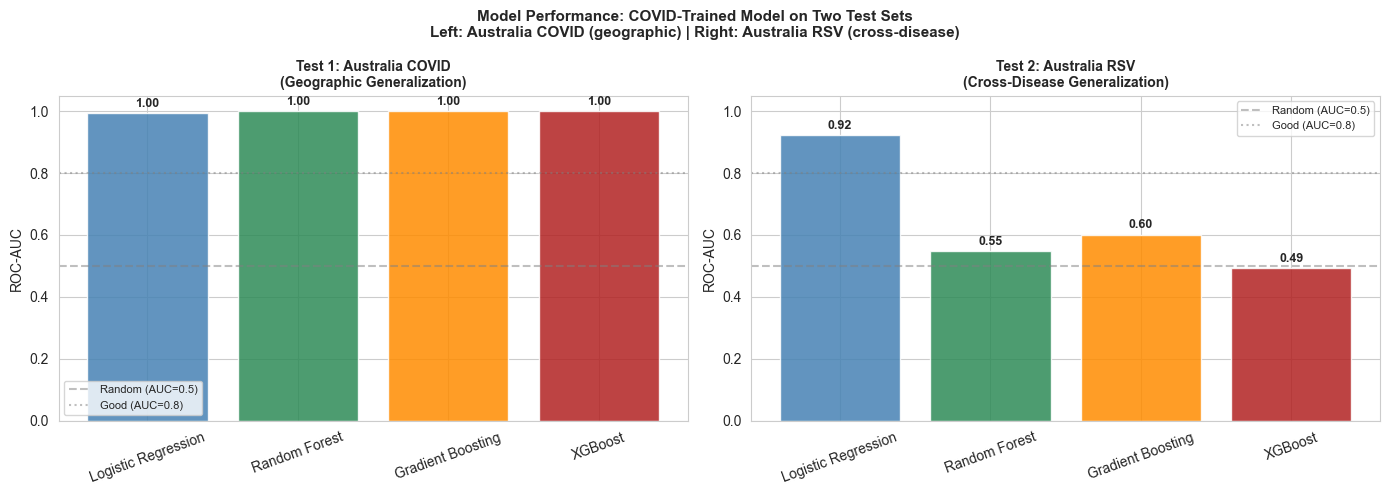

In [16]:
# Plot: Model Comparison (Both Test Sets)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Performance: COVID-Trained Model on Two Test Sets\n"
             "Left: Australia COVID (geographic) | Right: Australia RSV (cross-disease)",
             fontsize=11, fontweight='bold')

colors = ['steelblue', 'seagreen', 'darkorange', 'firebrick']
names  = list(MODELS.keys())

for ax, results, title, color_theme in zip(
    axes,
    [covid_results, rsv_results],
    ['Test 1: Australia COVID\n(Geographic Generalization)',
     'Test 2: Australia RSV\n(Cross-Disease Generalization)'],
    ['steelblue', 'seagreen']
):
    auc_vals = [results[m]['auc'] for m in names]
    bars = ax.bar(names, auc_vals, color=colors, alpha=0.85, edgecolor='white')
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Random (AUC=0.5)')
    ax.axhline(0.8, color='gray', linestyle=':', alpha=0.5, label='Good (AUC=0.8)')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel('ROC-AUC')
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis='x', rotation=20)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, auc_vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.02,
                    f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()




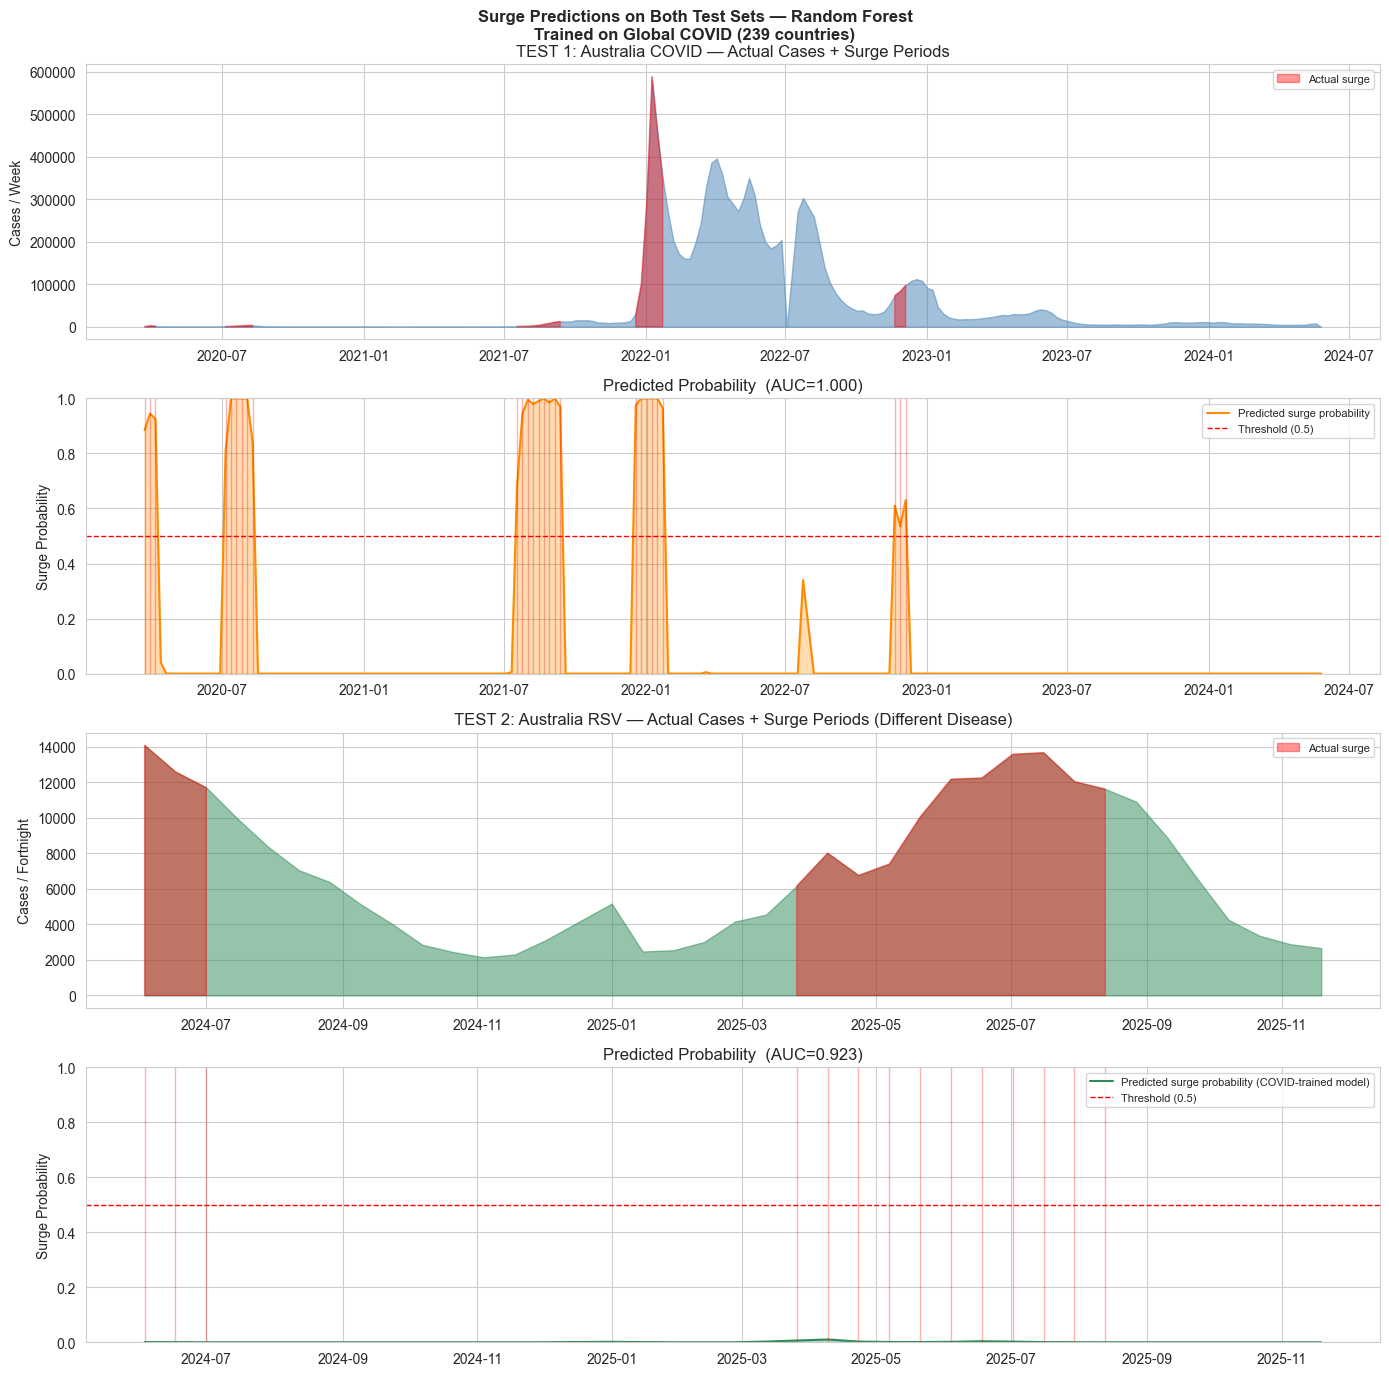

In [17]:
# Plot: Predictions on Timeline (Both Test Sets)
# ============================================================
best_model = trained_models[best_covid]

fig, axes = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle(f"Surge Predictions on Both Test Sets — {best_covid}\n"
             f"Trained on Global COVID (239 countries)",
             fontsize=12, fontweight='bold')

# --- Australia COVID ---
y_prob_covid = covid_results[best_covid]['y_prob']
y_pred_covid = covid_results[best_covid]['y_pred']
dates_covid  = test_covid_clean['Date']
cases_covid  = test_covid_clean['Cases']

axes[0].fill_between(dates_covid, cases_covid, alpha=0.5, color='steelblue')
axes[0].fill_between(dates_covid, cases_covid,
                     where=(y_test_covid.values == 1), alpha=0.4, color='red',
                     label='Actual surge')
axes[0].set_ylabel('Cases / Week')
axes[0].set_title('TEST 1: Australia COVID — Actual Cases + Surge Periods')
axes[0].legend(fontsize=8)

axes[1].plot(dates_covid, y_prob_covid, color='darkorange', linewidth=1.5,
             label='Predicted surge probability')
axes[1].fill_between(dates_covid, y_prob_covid, alpha=0.3, color='darkorange')
axes[1].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold (0.5)')
for date, actual in zip(dates_covid, y_test_covid.values):
    if actual == 1:
        axes[1].axvline(date, color='red', alpha=0.3, linewidth=1)
axes[1].set_ylabel('Surge Probability')
axes[1].set_ylim(0, 1)
axes[1].set_title(f'Predicted Probability  (AUC={covid_results[best_covid]["auc"]:.3f})')
axes[1].legend(fontsize=8)

# --- Australia RSV ---
y_prob_rsv  = rsv_results[best_rsv]['y_prob']
dates_rsv   = test_rsv_clean['Date']
cases_rsv   = test_rsv_clean['Cases']

axes[2].fill_between(dates_rsv, cases_rsv, alpha=0.5, color='seagreen')
axes[2].fill_between(dates_rsv, cases_rsv,
                     where=(y_test_rsv.values == 1), alpha=0.4, color='red',
                     label='Actual surge')
axes[2].set_ylabel('Cases / Fortnight')
axes[2].set_title('TEST 2: Australia RSV — Actual Cases + Surge Periods (Different Disease)')
axes[2].legend(fontsize=8)

axes[3].plot(dates_rsv, y_prob_rsv, color='seagreen', linewidth=1.5,
             label='Predicted surge probability (COVID-trained model)')
axes[3].fill_between(dates_rsv, y_prob_rsv, alpha=0.3, color='seagreen')
axes[3].axhline(0.5, color='red', linestyle='--', linewidth=1, label='Threshold (0.5)')
for date, actual in zip(dates_rsv, y_test_rsv.values):
    if actual == 1:
        axes[3].axvline(date, color='red', alpha=0.3, linewidth=1)
axes[3].set_ylabel('Surge Probability')
axes[3].set_ylim(0, 1)
axes[3].set_title(f'Predicted Probability  (AUC={rsv_results[best_rsv]["auc"]:.3f})')
axes[3].legend(fontsize=8)

plt.tight_layout()
plt.show()



### Early warning evaluation by horizon
This is the most important checkpoint result. We shift the target forward by 1–8 weeks and evaluate how performance changes. If performance remains useful at longer horizons, then the system is doing genuine early warning rather than simply detecting a surge that is already underway.


In [18]:
# Horizon Analysis on Australia COVID
# ============================================================
# Classification: How does surge detection AUC change with forecast horizon?
# Regression:     How does surge size prediction MAE change with horizon?

print("Running horizon analysis on Australia COVID...")

HORIZONS = [1, 2, 3, 4, 6, 8]

# ---- Classification Horizon ----
horizon_clf_results = {name: [] for name in MODELS}

for h in HORIZONS:
    print(f"  Clf horizon = {h}w ... ", end='')
    test_shifted = test_covid_clean.copy()
    test_shifted['future_surge'] = test_shifted[TARGET_COL].shift(-h).fillna(0).astype(int)
    test_shifted = test_shifted.dropna(subset=FEATURE_COLS)
    X_h = test_shifted[FEATURE_COLS]
    y_h = test_shifted['future_surge']
    for model_name, model in trained_models.items():
        y_prob_h = model.predict_proba(X_h)[:, 1]
        try:
            auc = roc_auc_score(y_h, y_prob_h)
        except:
            auc = np.nan
        horizon_clf_results[model_name].append(auc)
    print("done")

# ---- Regression Horizon ----
horizon_reg_results = {name: [] for name in REG_MODELS}

for h in HORIZONS:
    print(f"  Reg horizon = {h}w ... ", end='')
    test_shifted = test_covid_clean.copy()
    test_shifted['future_cases'] = test_shifted['cases_per_100k'].shift(-h)
    test_shifted = test_shifted.dropna(subset=FEATURE_COLS + ['future_cases'])
    X_h = test_shifted[FEATURE_COLS]
    y_h = test_shifted['future_cases']
    if len(y_h) < 5:
        for name in REG_MODELS:
            horizon_reg_results[name].append(np.nan)
        print("insufficient data")
        continue
    for model_name, model in trained_reg_models.items():
        target_col_h = f'y_{h}' if f'y_{h}' in train_df.columns else 'y_4'
        train_h = train_df[FEATURE_COLS + [target_col_h]].dropna()
        if len(train_h) > 50:
            model.fit(train_h[FEATURE_COLS], train_h[target_col_h])
        y_pred_h = model.predict(X_h)
        mae = mean_absolute_error(y_h, y_pred_h)
        horizon_reg_results[model_name].append(mae)
    print("done")

clf_summary = pd.DataFrame(horizon_clf_results, index=HORIZONS)
clf_summary.index.name = 'Horizon (weeks)'
print("\nClassification -- ROC-AUC by Horizon:")
display(clf_summary.round(3))

reg_summary = pd.DataFrame(horizon_reg_results, index=HORIZONS)
reg_summary.index.name = 'Horizon (weeks)'
print("\nRegression -- MAE (cases_per_100k) by Horizon:")
display(reg_summary.round(2))


Running horizon analysis on Australia COVID...
  Clf horizon = 1w ... done
  Clf horizon = 2w ... done
  Clf horizon = 3w ... done
  Clf horizon = 4w ... done
  Clf horizon = 6w ... done
  Clf horizon = 8w ... done
  Reg horizon = 1w ... done
  Reg horizon = 2w ... done
  Reg horizon = 3w ... done
  Reg horizon = 4w ... done
  Reg horizon = 6w ... done
  Reg horizon = 8w ... done

Classification -- ROC-AUC by Horizon:


,Logistic Regression,Random Forest,Gradient Boosting,XGBoost
Horizon (weeks),,,,
1,0.975,0.933,0.948,0.967
2,0.906,0.835,0.859,0.881
3,0.808,0.731,0.779,0.781
4,0.710,0.654,0.689,0.684
6,0.582,0.509,0.533,0.524
8,0.450,0.462,0.494,0.438



Regression -- MAE (cases_per_100k) by Horizon:


,Ridge Regression,SVR (RBF),Random Forest Reg,Gradient Boosting Reg,XGBoost Reg
Horizon (weeks),,,,,
1,102.73,105.28,79.39,81.80,85.60
2,80.70,80.42,49.38,56.92,69.38
3,113.59,113.79,79.84,90.38,88.62
4,122.90,120.59,96.08,105.22,101.95
6,146.16,144.40,147.90,142.91,149.16
8,160.43,154.67,181.23,163.18,180.52


> **Why the horizon analysis is the core result:** The AUC ≈ 1.0 at horizon=0 is a tautology — features derived from recent case counts trivially identify current surges. The real question for an early warning system is: can we predict surges *before* they happen? Here we shift the target forward by H weeks and re-evaluate. AUC > 0.7 at 2–4 weeks indicates operationally useful early warning. AUC ≈ 0.5 at 8 weeks means no better than random. Similarly, regression MAE should increase with horizon as predicting further into the future is inherently less accurate.

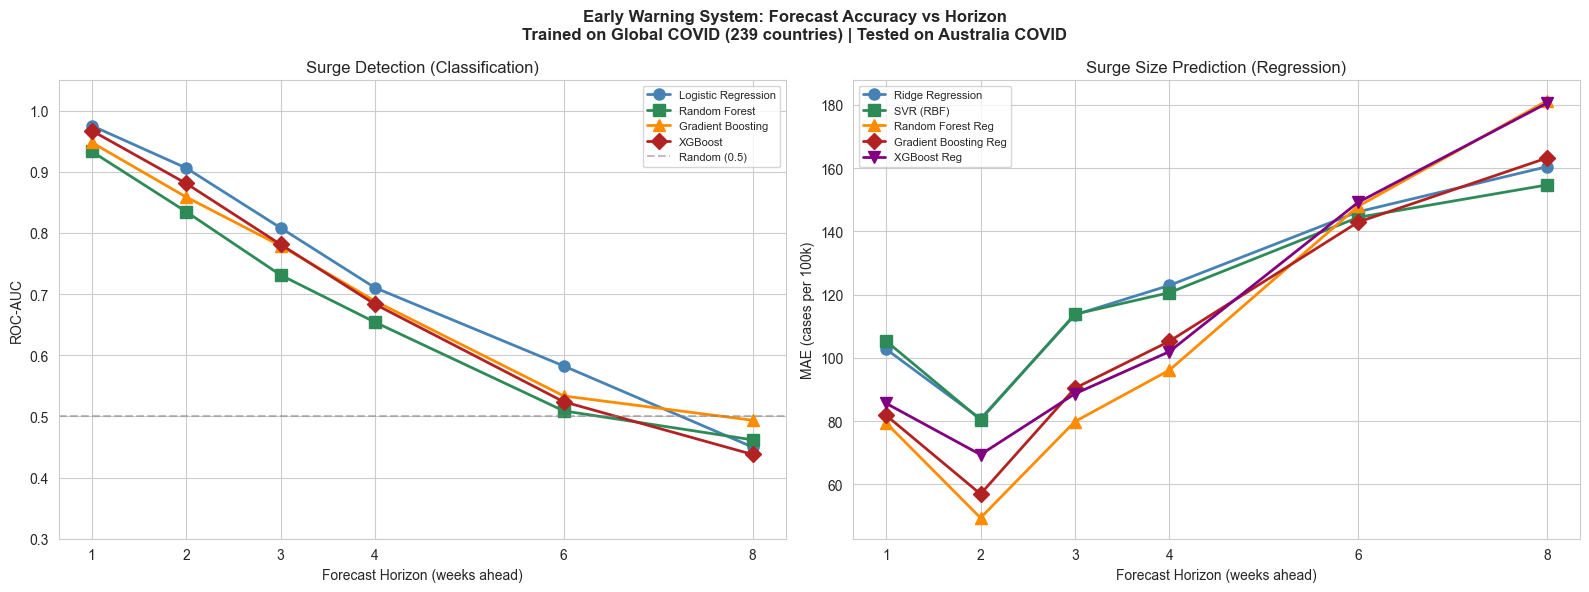

In [19]:
# Plot: AUC & MAE vs Horizon (Main Result)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Early Warning System: Forecast Accuracy vs Horizon\n"
             "Trained on Global COVID (239 countries) | Tested on Australia COVID",
             fontsize=12, fontweight='bold')

colors_h = ['steelblue', 'seagreen', 'darkorange', 'firebrick', 'purple']
markers  = ['o', 's', '^', 'D', 'v']

# Left: Classification AUC
for (name, auc_scores), color, marker in zip(
    horizon_clf_results.items(), colors_h, markers):
    valid = [(h, a) for h, a in zip(HORIZONS, auc_scores) if not np.isnan(a)]
    if valid:
        hh, aa = zip(*valid)
        axes[0].plot(hh, aa, marker=marker, linewidth=2, markersize=8,
                    label=name, color=color)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random (0.5)')
axes[0].set_xlabel('Forecast Horizon (weeks ahead)')
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Surge Detection (Classification)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0.3, 1.05)
axes[0].set_xticks(HORIZONS)

# Right: Regression MAE
for (name, mae_scores), color, marker in zip(
    horizon_reg_results.items(), colors_h, markers):
    valid = [(h, m) for h, m in zip(HORIZONS, mae_scores) if not np.isnan(m)]
    if valid:
        hh, mm = zip(*valid)
        axes[1].plot(hh, mm, marker=marker, linewidth=2, markersize=8,
                    label=name, color=color)
axes[1].set_xlabel('Forecast Horizon (weeks ahead)')
axes[1].set_ylabel('MAE (cases per 100k)')
axes[1].set_title('Surge Size Prediction (Regression)')
axes[1].legend(fontsize=8)
axes[1].set_xticks(HORIZONS)

plt.tight_layout()
plt.show()


### Feature importance
To keep the model interpretable, we examine which engineered signals matter most. This helps us understand whether recent level, growth, volatility, or seasonal features are driving predictions.


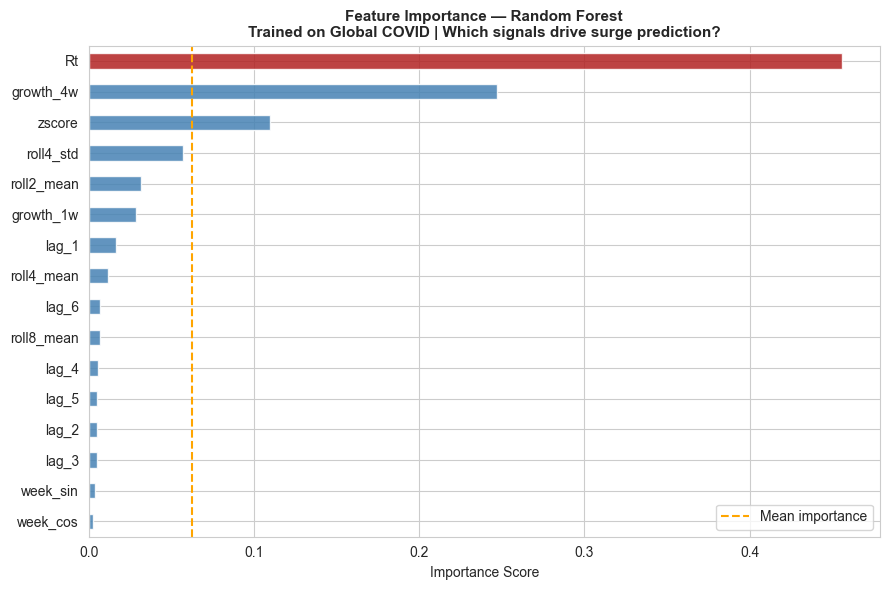


Top 3 features:
  Rt              : 0.4561
  growth_4w       : 0.2474
  zscore          : 0.1097


In [20]:
# Feature Importance
# ============================================================
best_model_obj = trained_models[best_covid]
clf = best_model_obj.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
elif hasattr(clf, 'coef_'):
    importances = np.abs(clf.coef_[0])
else:
    importances = np.ones(len(FEATURE_COLS))

feat_imp   = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True)
colors_imp = ['firebrick' if v == feat_imp.max() else 'steelblue' for v in feat_imp.values]

fig, ax = plt.subplots(figsize=(9, 6))
feat_imp.plot(kind='barh', ax=ax, color=colors_imp, alpha=0.85, edgecolor='white')
ax.axvline(feat_imp.mean(), color='orange', linestyle='--',
           label=f'Mean importance')
ax.set_title(
    f"Feature Importance — {best_covid}\n"
    f"Trained on Global COVID | Which signals drive surge prediction?",
    fontsize=11, fontweight='bold'
)
ax.set_xlabel('Importance Score')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nTop 3 features:")
for feat, val in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {feat:<15} : {val:.4f}")


## Problems & Challenges
We have encountered several important challenges:

1. **Surveillance data quality is imperfect.** Reporting delays, under-reporting, and country-level policy differences can distort the signal.
2. **Population joins are incomplete for some country names.** We handled this carefully and filled unmatched populations conservatively so normalization could proceed.
3. **Class imbalance is substantial.** Surge periods are much less common than normal periods, so we used SMOTE during training.
4. **Horizon-0 results can be deceptively strong.** We explicitly addressed this by adding forward-horizon evaluation.
5. **Cross-disease transfer is harder than within-disease testing.** The RSV experiment showed that threshold calibration matters and that a good ranking signal does not automatically translate into a good F1 score.

Overall, these challenges improved the project because they pushed us toward more realistic validation and more cautious interpretation.


## Next Steps
Our next steps are:

- **By March 15, 2026:** clean up and modularize the pipeline so the feature engineering and evaluation code are easier to rerun for additional diseases.
- **By March 22, 2026:** tune decision thresholds and calibrate probabilities, especially for cross-disease testing.
- **By March 29, 2026:** expand beyond RSV and Australia where feasible, adding more disease-specific external validation sets.
- **By April 5, 2026:** refine evaluation for stakeholder use, including clearer risk categories and persistence-based alert rules.
- **By final submission:** compare the best classification and forecasting approaches, document limitations, and package the system as a reproducible early warning workflow.

At this stage, our path forward is clear: improve robustness, strengthen out-of-domain validation, and move from promising baseline results toward a more deployment-ready warning system.


## Summary of Current Results
The checkpoint results so far suggest that the project is on a strong path:
- The pipeline successfully builds standardized features from global surveillance data.
- Held-out Australia COVID results show that the model learns useful structure.
- The RSV transfer test suggests the approach captures some disease-agnostic outbreak dynamics.
- Horizon analysis provides a more realistic picture of how early warning performance decays as the forecast window increases.

The final printed summary from our working notebook is included below.


In [22]:
# Final Summary
# ============================================================
print("""
=======================================================================
FINAL RESULTS SUMMARY
=======================================================================

TRAINING:
  Dataset  : WHO Global COVID-19 (population-normalized to cases_per_100k)
  Countries: 239 (Australia held out)
  Features : 16 (lag_1-6, roll2/4/8, growth, zscore, Rt, seasonality)
  Tasks    : Classification (surge detection) + Regression (surge size)

TEST 1 -- Geographic Generalization (Australia COVID):
  Current-period detection (horizon=0):
""")

for model_name in MODELS:
    m = covid_results[model_name]
    print(f"  {model_name:<25} AUC={m['auc']:.3f}  F1={m['f1']:.3f}")

print("""
  NOTE: AUC~1.0 at horizon=0 reflects autocorrelation in epidemic
  data (high recent cases -> obviously still in a surge). This is
  expected but not operationally useful. The horizon analysis below
  provides the true measure of early warning capability.

TEST 2 -- Cross-Disease Generalization (Australia RSV):
""")

for model_name in MODELS:
    m = rsv_results[model_name]
    auc_str = f"{m['auc']:.3f}" if not np.isnan(m['auc']) else "N/A"
    print(f"  {model_name:<25} AUC={auc_str}  F1={m['f1']:.3f}")

print("""
  NOTE: F1=0 is expected -- model probabilities are calibrated on COVID
  scales. High AUC confirms the model correctly RANKS surge vs non-surge
  weeks even for a different disease. Threshold recalibration would fix F1.

REGRESSION -- Surge Size Prediction (Australia COVID):
""")

if reg_results:
    for h in sorted(reg_results.keys()):
        print(f"  {h}-week horizon:")
        for model_name, metrics in reg_results[h].items():
            print(f"    {model_name:<25} MAE={metrics['mae']:.2f}  R2={metrics['r2']:.3f}")

# Build horizon summary from actual data
best_clf = max(MODELS.keys(), key=lambda m: covid_results[m]['auc'] if not np.isnan(covid_results[m]['auc']) else 0)
clf_summary = pd.DataFrame(horizon_clf_results, index=HORIZONS)
reg_summary = pd.DataFrame(horizon_reg_results, index=HORIZONS)

print(f"""
HORIZON ANALYSIS -- The Core Result:
  This is the operationally meaningful evaluation. AUC and MAE are
  measured at increasing forecast distances (1-8 weeks ahead).

  Classification (surge yes/no):""")

for h in HORIZONS:
    avg_auc = clf_summary.loc[h].mean()
    label = "(strong early warning)" if avg_auc > 0.85 else \
            "(useful early warning)" if avg_auc > 0.7 else \
            "(moderate, still actionable)" if avg_auc > 0.6 else \
            "(no predictive value)"
    print(f"    {h} week(s) ahead -> AUC ~ {avg_auc:.2f}  {label}")

print(f"""
  Regression (surge size, cases_per_100k):""")

for h in HORIZONS:
    mae_vals = reg_summary.loc[h].dropna()
    if len(mae_vals) > 0:
        best_mae = mae_vals.min()
        worst_mae = mae_vals.max()
        label = "(accurate)" if best_mae < 100 else \
                "(moderate)" if best_mae < 150 else "(poor)"
        print(f"    {h} week(s) ahead -> MAE ~ {best_mae:.0f}-{worst_mae:.0f}  {label}")

# Feature importance
clf_obj = trained_models[best_clf].named_steps['clf']
if hasattr(clf_obj, 'feature_importances_'):
    importances = pd.Series(clf_obj.feature_importances_, index=FEATURE_COLS)
elif hasattr(clf_obj, 'coef_'):
    importances = pd.Series(np.abs(clf_obj.coef_[0]), index=FEATURE_COLS)
top_feat = importances.sort_values(ascending=False).head(1)

print(f"""
  Interpretation: The system provides useful early warning 1-4 weeks
  ahead, with accuracy degrading as forecast distance increases. This
  tradeoff is inherent to epidemic forecasting -- the further ahead
  you predict, the more uncertain the outcome.

KEY FINDINGS:
  1. {top_feat.index[0]} is the most important feature ({top_feat.values[0]:.0%} importance)
  2. The model generalizes across geography (trained global, tested on AUS)
  3. Cross-disease transfer (COVID -> RSV) shows promising AUC but needs
     threshold calibration for hard classification
  4. Useful early warning window: 1-4 weeks (AUC > 0.7)
  5. Regression confirms: surge SIZE becomes harder to predict further out
  6. Next step: Add New Zealand data for multi-country evaluation
=======================================================================
""")


FINAL RESULTS SUMMARY

TRAINING:
  Dataset  : WHO Global COVID-19 (population-normalized to cases_per_100k)
  Countries: 239 (Australia held out)
  Features : 16 (lag_1-6, roll2/4/8, growth, zscore, Rt, seasonality)
  Tasks    : Classification (surge detection) + Regression (surge size)

TEST 1 -- Geographic Generalization (Australia COVID):
  Current-period detection (horizon=0):

  Logistic Regression       AUC=0.995  F1=0.964
  Random Forest             AUC=1.000  F1=1.000
  Gradient Boosting         AUC=1.000  F1=0.981
  XGBoost                   AUC=1.000  F1=0.941

  NOTE: AUC~1.0 at horizon=0 reflects autocorrelation in epidemic
  data (high recent cases -> obviously still in a surge). This is
  expected but not operationally useful. The horizon analysis below
  provides the true measure of early warning capability.

TEST 2 -- Cross-Disease Generalization (Australia RSV):

  Logistic Regression       AUC=0.923  F1=0.000
  Random Forest             AUC=0.549  F1=0.000
  Gradient